In [1]:
# Upgraded Project Improvements:
    # Enhanced Feature Representation
        # Utilizes the BLOSUM62 substitution matrix to capture evolutionary amino acid substitution patterns.
        # Provides biologically meaningful information about how conservative or disruptive a mutation is.
        # Distinguishes substitutions that are commonly tolerated from those that are evolutionarily rare.
        # Replaces simple categorical amino acid encoding with biologically informed substitution scores.

In [2]:
# Loads the pandas library
# Allows to use pd as an alias instead of typing pandas every time we want to use it
import pandas as pd

# Imports Python's modern path-handling system 
from pathlib import Path

# Defines a function to automatically find the main project folder 
def find_root():
    # Sets variable p to current working directory (Ex: Notebooks/01_MutationProj.ipynb)
    p = Path.cwd()
    # Loop that continues moving upward through parent directories until top of filesystem is reached (Cancer-Mutation-Classification-TensorFlow)
    while p != p.parent:
        # Checks to see if file .projectroot exists inside p directory by appending .projectroot to p
        # If found, returns the directory containing projectroot 
        if (p / ".projectroot").exists():
            return p
        # If projectroot not found, moves up one folder and continues loop again 
        p = p.parent
    # Searched to the top of the filesystem without finding project root
    raise FileNotFoundError("Project root not found")

# Sets ROOT to the directory containing .projectroot (Cancer-Mutation-Classification-TensorFlow)
ROOT = find_root()

# Appends "Datasets" folder to the root (Ex: Cancer-Mutation-Classification-TensorFlow/Datasets)
DATA_DIR = ROOT / "Datasets"

# Creates a Path object pointing to each of the file locations 
brca1_path = DATA_DIR / "Data_BRCA1.txt"
brca2_path = DATA_DIR / "Data_BRCA2.txt"
tp53_path = DATA_DIR / "Data_TP53.txt"

# Reads the file located at each of the paths and creates a pandas Dataframe for each gene 
# Tells pandas that the columns in each of the files are tab-separated (sep="\t")
brca1_df = pd.read_csv(brca1_path, sep="\t")
brca2_df = pd.read_csv(brca2_path, sep="\t")
tp53_df = pd.read_csv(tp53_path, sep="\t")

# Creates a new "gene" column in each of the gene dataframes and sets it equal to the respective gene name 
tp53_df["gene"] = "TP53"
brca1_df["gene"] = "BRCA1"
brca2_df["gene"] = "BRCA2"

# Combines all of the dataframes into one dataframe
# ignore_index=True resets the index of the combined dataframe to be sequential from 0 to N-1
# N is the total number of rows in the combine dataframe 
combined_df = pd.concat([brca1_df, brca2_df, tp53_df], ignore_index=True)

# Splits the "Name" column into three new columns: "ref_aa", "position", and "mut_aa" based on string 
combined_df[["ref_aa", "position", "mut_aa"]] = combined_df["Name"].str.extract(
    r"p\.([A-Za-z]+)(\d+)([A-Za-z]+)"
)

# Defines a function that takes in a string, returns either Benign or Pathogenic
# Converts "Likely Pathogenic" classification into Pathogenic Classification
# Converts "Likely Benign" classification into Benign Classification
def clean_label(x):
     x = str(x).lower()
     if "benign" in x and "pathogenic" not in x:
         return "Benign"
     elif "pathogenic" in x:
         return "Pathogenic"
     else:
         return "Other"
     
# Creates a new column "Classification"
# Sets it equal to the Germline classification column after applying the clean_label function to it
combined_df["Classification"] = combined_df["Germline classification"].apply(clean_label)

In [3]:
# Imports the numpy library, uses the alias np so that it can be used instead of typing numpy every time
import numpy as np

# Creates a new DataFrame called hot_encoding
# hot_encoding only contains the columns: "ref_aa", "position", "mut_aa", "Classification", and "gene" from combined_df
# .copy() prevents changes to hot_encoding that could affect original_df data
hot_encoding = combined_df[["ref_aa", "position", "mut_aa", "Classification", "gene"]].copy()

# Replaces any rows that have "del" or "fs" in the "mut_aa" column, with "nan"
# "nan" are considered missing values, frameshift mutations, or deletions 
# Drops all rows that had "nan" in the original data and the newly introduced "nan" values from previous step
pd.set_option('display.max_rows', None)
hot_encoding["mut_aa"] = hot_encoding["mut_aa"].replace("del", np.nan)
hot_encoding["mut_aa"] = hot_encoding["mut_aa"].replace("fs", np.nan)
hot_encoding = hot_encoding.dropna(subset=[
    "ref_aa",
    "position",
    "mut_aa",
    "Classification"
])

# Displays the first 5 rows of the hot_encoding dataframe
hot_encoding.head()

,ref_aa,position,mut_aa,Classification,gene
0,His,1862,Leu,Benign,BRCA1
1,His,1860,Pro,Benign,BRCA1
2,Pro,1859,Arg,Benign,BRCA1
3,Ile,1858,Leu,Benign,BRCA1
4,Pro,1856,Ser,Benign,BRCA1


In [4]:
# Displays sample number for each gene in data frame 
hot_encoding["gene"].value_counts().rename_axis("Gene").reset_index(name="Sample Number")

,Gene,Sample Number
0,BRCA2,681
1,BRCA1,606
2,TP53,393


In [5]:
# Creates a frequency table of Classification labels with counts for Benign and Pathogenic across all genes
hot_encoding["Classification"].value_counts().rename_axis("Class").reset_index(name="Count")

,Class,Count
0,Benign,1086
1,Pathogenic,594


In [6]:
# Displays the count of Pathogenic and Benign samples for individual genes across five different genes
hot_encoding.groupby("gene")["Classification"].value_counts()

gene   Classification
BRCA1  Benign            371
       Pathogenic        235
BRCA2  Benign            566
       Pathogenic        115
TP53   Pathogenic        244
       Benign            149
Name: count, dtype: int64

In [7]:
# Creates a list that:
# 1. Joins both the ref_aa and mut_aa columns
# 2. Removes duplicates using set()
# 3. Sorts the list alphabetically.

# Creates a dictionary that maps each amino acid to a unique index based on its position in the sorted list
aa_list = sorted(set(hot_encoding["ref_aa"]).union(set(hot_encoding["mut_aa"])))
aa_to_idx = {aa: i for i, aa in enumerate(aa_list)}

In [8]:
# Imports the numpy library, uses the alias np so that it can be used instead of typing numpy every time
import numpy as np

# Created an empty list X 
X = []

# Iterates through each row of the hot_encoding DataFrame using iterrows()
# Extract values for ref, mut, pos, and appends them as a list to X
# Ex: [3, 4, 175]
for _, row in hot_encoding.iterrows():
    ref = aa_to_idx[row["ref_aa"]]
    mut = aa_to_idx[row["mut_aa"]]
    pos = int(row["position"])

    X.append([ref, mut, pos])

# Created a numpy array from the list X, turns it into an efficient numerical matrix 
X = np.array(X)

In [9]:
# Creates a panda series that turns the classification column into a binary variable 
# .apply() is a panda features that iterates through each row by row  
y = hot_encoding["Classification"].apply(
    lambda x: 1 if "pathogenic" in x.lower() else 0
)

# Created a numpy array from the panda series y, turns it into an efficient numerical vector
y = np.array(y)

In [10]:
# Created a nested dictionary that contains the properties of each amino acid, such as charge, polarity, hydrophobicity, and size
# Negative charge represented as -1, positive charge represented as 1, and neutral charge represented as 0
# Polarity encoded numerically, represented as positive for polar amino acids and negative for non-polar amino acids
# Size represented amino acid r-chain size, with larger numbers indicating larger amino acids
aa_properties = {
    "Ala": {"charge": 0, "polarity": 0, "hydrophobicity": 1.8, "size": 1},
    "Arg": {"charge": 1, "polarity": 1, "hydrophobicity": -4.5, "size": 3},
    "Asn": {"charge": 0, "polarity": 1, "hydrophobicity": -3.5, "size": 2},
    "Asp": {"charge": -1, "polarity": 1, "hydrophobicity": -3.5, "size": 2},
    "Cys": {"charge": 0, "polarity": 0, "hydrophobicity": 2.5, "size": 2},
    "Gln": {"charge": 0, "polarity": 1, "hydrophobicity": -3.5, "size": 3},
    "Glu": {"charge": -1, "polarity": 1, "hydrophobicity": -3.5, "size": 3},
    "Gly": {"charge": 0, "polarity": 0, "hydrophobicity": -0.4, "size": 1},
    "His": {"charge": 1, "polarity": 1, "hydrophobicity": -3.2, "size": 3},
    "Ile": {"charge": 0, "polarity": 0, "hydrophobicity": 4.5, "size": 3},
    "Leu": {"charge": 0, "polarity": 0, "hydrophobicity": 3.8, "size": 3},
    "Lys": {"charge": 1, "polarity": 1, "hydrophobicity": -3.9, "size": 3},
    "Met": {"charge": 0, "polarity": 0, "hydrophobicity": 1.9, "size": 3},
    "Phe": {"charge": 0, "polarity": 0, "hydrophobicity": 2.8, "size": 3},
    "Pro": {"charge": 0, "polarity": 0, "hydrophobicity": -1.6, "size": 2},
    "Ser": {"charge": 0, "polarity": 1, "hydrophobicity": -0.8, "size": 2},
    "Thr": {"charge": 0, "polarity": 1, "hydrophobicity": -0.7, "size": 2},
    "Trp": {"charge": 0, "polarity": 0, "hydrophobicity": -0.9, "size": 4},
    "Tyr": {"charge": 0, "polarity": 1, "hydrophobicity": -1.3, "size": 3},
    "Val": {"charge": 0, "polarity": 0, "hydrophobicity": 4.2, "size": 2}
}

In [11]:
# Imports the substitution_matrices library
# Used to load the BLOSUM62 amino acid substitution matrix
from Bio.Align import substitution_matrices

# Loads the BLOSUM62 matrix, which assigns evolutionary substitution scores
# Based on how frequently amino acid substitutions are observed in conserved proteins
blosum62 = substitution_matrices.load("BLOSUM62")

# Maps three-letter amino acid abbreviations to one-letter abbreviations
aa_3to1 = {
    "Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D",
    "Cys": "C", "Gln": "Q", "Glu": "E", "Gly": "G",
    "His": "H", "Ile": "I", "Leu": "L", "Lys": "K",
    "Met": "M", "Phe": "F", "Pro": "P", "Ser": "S",
    "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V"
}

In [12]:
import numpy as np

# Creates empty lists X and y to store the features and labels for the machine learning model
X = []
y = []

gene_onehot = pd.get_dummies(hot_encoding["gene"])

# Iterates through each row of the hot_encoding DataFrame using iterrows()
for _, row in hot_encoding.iterrows():
    ref = row["ref_aa"]
    mut = row["mut_aa"]

    # Checks if the reference and mutant amino acids are present in the aa_properties dictionary, if not, it skips to the next iteration
    if ref not in aa_properties or mut not in aa_properties:
        continue

    # Converts the reference and mutant amino acids from three-letter to one-letter abbreviations
    ref_1 = aa_3to1[ref]
    mut_1 = aa_3to1[mut]

    # Retrieves the BLOSUM62 evolutionary substitution score for the amino acid change
    blosum_score = blosum62[(ref_1, mut_1)]

    # Retrieves the physicochemical properties of the reference and mutant amino acids
    ref_p = aa_properties[ref]
    mut_p = aa_properties[mut]

    # Appends a list of features to X for each mutation, including the position of the mutation and the differences in properties between the mutant and reference amino acids
    features = [
        int(row["position"]),
        mut_p["charge"] - ref_p["charge"],
        mut_p["polarity"] - ref_p["polarity"],
        mut_p["hydrophobicity"] - ref_p["hydrophobicity"],
        mut_p["size"] - ref_p["size"],
        blosum_score
    ]

    gene_vec = gene_onehot.loc[_].values.tolist()
    
    X.append(features + gene_vec)

    # Appends a binary label to y for each mutation, where 1 indicates pathogenic and 0 indicates benign
    label = row["Classification"]
    y.append(1 if "pathogenic" in str(label).lower() else 0)

# Converts the lists X and y into numpy arrays of type float32, which are more efficient for numerical computations in machine learning models
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

In [13]:
# Imports the tensorflow library, uses the alias tf so that it can be used instead of typing tensorflow every time
import tensorflow as tf

def build_model():

    # Sequential model is a linear stack of layers, allows us to build a neural network by adding layers one after the other
    model = tf.keras.Sequential([

        # Tells the model how many features each input sample has
        tf.keras.Input(shape=(X_train.shape[1],)),

        # First layer is a Dense layer with 16 neurons, ReLU activation function (introduces non-linearity), and input shape equal to the number of features in X_train
        tf.keras.layers.Dense(16, activation='relu'),

        # Second layer is a Dense layer with 8 neurons and ReLU activation function (introduces non-linearity)
        # Refines patterns learned from first layer
        tf.keras.layers.Dense(8, activation='relu'),

        # Final layer is a Dense layer with 1 neuron and sigmoid activation function (outputs a value between 0 and 1, representing the probability of being pathogenic)
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    # Configures how the model will learn, tells network how update itself and how to measure performance
    # Adam controls how the model updates its weights during training
    # Binary crossentropy is used for binary classification problems, measures the difference between predicted probabilities and actual labels
    # Accuracy is used as a metric to evaluate the performance of the model during training and testing
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
import numpy as np

# Imports functions from scikit-learn library that allow us to evaluate the performance of our model
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Imports a function from scikit-learn library that allows us to split our data into training and testing sets
from sklearn.model_selection import train_test_split

# Imports a function from scikit-learn library that allows us to handle imbalanced datasets by penalizing misclassifications of the minority class more heavily during training
from sklearn.utils.class_weight import compute_class_weight

accuracies = []
f1_scores_pathogenic = []
f1_scores_benign = []
recall_scores_pathogenic = []
recall_scores_benign = []
precision_scores_pathogenic = []
precision_scores_benign = []

classes = np.unique(y)

# Computes balanced class weights based on the frequency of each class
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)

# Maps each class label to its corresponding weight
class_weight = dict(zip(classes, weights))

for i in range(50):

    # 20% of the data is reserved for testing (X_test, y_test), 80% is used for training (x_train, y_train)
    # Use a different random_state for each iteration so each run evaluates the model on a different stratified train/test split
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=i
    )

    # Controls NumPy's randomness
    np.random.seed(42)

    # Controls TensorFlow's randomness 
    tf.random.set_seed(42)

    # 1. Rebuild model each time
    model = build_model()

    # 2. Trains the model on the training data for 10 epochs (iterations over the entire dataset)
    # Batch size of 16 means the model will update its weights after processing every 16 samples within each epoch 
    # Validation split: Within X_train (which is 80% of the full dataset), 80% is used to train the model (64% of total data), and 20% is set aside for validation (16% of total data)
    # Validation Accuracy is accuracy on unseen-in-training data
        # Goes up after each epoch, signifies that the model is in fact learning useful patterns
    # Validation data is what the model uses to evaluate its performance after each epoch (accuracy, loss, val_accuracy, val_loss)
    # Overfitting: Too many epochs can decrease accuracy because the model begins to memorize training data which doesn't generalize to the validation data
    model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0, validation_split = 0.2, class_weight=class_weight,)

    # 3. Model outputs a probability
    # Probability greater than 0.5, than predicts test sample as pathogenic (1)
    # If probability is less than 0.5 than predicts test sample as benign (0)
    y_prob = model.predict(X_test, verbose=0).ravel()    
    y_pred = (y_prob > 0.5).astype(int)

    # 4. Calculates both Pathogenic and Benign accuracy, f1 score, recall, and precision for each iteration
    # pos_label=1 indicates pathogenic
    # pos_label=0 indicates benign 
    acc = accuracy_score(y_test, y_pred)
    f1_pathogenic = f1_score(y_test, y_pred, pos_label=1)
    f1_benign = f1_score(y_test, y_pred,pos_label=0)
    recall_pathogenic = recall_score(y_test, y_pred, pos_label=1)
    recall_benign = recall_score(y_test, y_pred, pos_label=0)
    precision_pathogenic = precision_score(y_test, y_pred, pos_label=1)
    precision_benign = precision_score(y_test, y_pred, pos_label=0)
    accuracies.append(acc)

    # Appends the 50 scores to each of the lists for each metric 
    f1_scores_pathogenic.append(f1_pathogenic)
    f1_scores_benign.append(f1_benign)
    recall_scores_pathogenic.append(recall_pathogenic)
    recall_scores_benign.append(recall_benign)
    precision_scores_pathogenic.append(precision_pathogenic)
    precision_scores_benign.append(precision_benign)

# Calculates the mean and 95% confidence interval across repeated model runs
def mean_ci(data):
    data = np.array(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)

    margin = 1.96 * (std / np.sqrt(n))  # 95% CI

    lower = mean - margin
    upper = mean + margin
    return mean, lower, upper

results = []

# Adds the mean and 95% confidence interval for a performance metric to the results table 
def add_row(metric, mean, lower, upper):
    results.append({
        "Metric": metric,
        "Mean": round(mean, 3),
        "CI Lower": round(lower, 3),
        "CI Upper": round(upper, 3),
        "CI (range)": f"({round(lower,3)}, {round(upper,3)})"
    })

acc_mean, acc_low, acc_high = mean_ci(accuracies)
add_row("Accuracy", acc_mean, acc_low, acc_high)

rec_p_mean, rec_p_low, rec_p_high = mean_ci(recall_scores_pathogenic)
add_row("Recall (Pathogenic)", rec_p_mean, rec_p_low, rec_p_high)

rec_b_mean, rec_b_low, rec_b_high = mean_ci(recall_scores_benign)
add_row("Recall (Benign)", rec_b_mean, rec_b_low, rec_b_high)

prec_p_mean, prec_p_low, prec_p_high = mean_ci(precision_scores_pathogenic)
add_row("Precision (Pathogenic)", prec_p_mean, prec_p_low, prec_p_high)

prec_b_mean, prec_b_low, prec_b_high = mean_ci(precision_scores_benign)
add_row("Precision (Benign)", prec_b_mean, prec_b_low, prec_b_high)

f1_p_mean, f1_p_low, f1_p_high = mean_ci(f1_scores_pathogenic)
add_row("F1 (Pathogenic)", f1_p_mean, f1_p_low, f1_p_high)

f1_b_mean, f1_b_low, f1_b_high = mean_ci(f1_scores_benign)
add_row("F1 (Benign)", f1_b_mean, f1_b_low, f1_b_high)

results_df = pd.DataFrame(results)
results_df

,Metric,Mean,CI Lower,CI Upper,CI (range)
0,Accuracy,0.644,0.612,0.675,"(0.612, 0.675)"
1,Recall (Pathogenic),0.606,0.537,0.676,"(0.537, 0.676)"
2,Recall (Benign),0.664,0.583,0.744,"(0.583, 0.744)"
3,Precision (Pathogenic),0.553,0.510,0.595,"(0.51, 0.595)"
4,Precision (Benign),0.787,0.767,0.807,"(0.767, 0.807)"
5,F1 (Pathogenic),0.528,0.497,0.558,"(0.497, 0.558)"
6,F1 (Benign),0.665,0.606,0.723,"(0.606, 0.723)"


In [15]:
# Imports the roc_curve, roc_auc_score libraries
# Computes the Receiver Operating Characteristic (ROC) curve 
# Computes the Area Under the ROC Curve (AUC) performance metric
from sklearn.metrics import roc_curve, roc_auc_score

# Imports the matplotlib.pyplot library, uses the alias plt so that it can be used instead of typing matplotlib.pyplot every time
# Used for creating graphs and visualizations
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

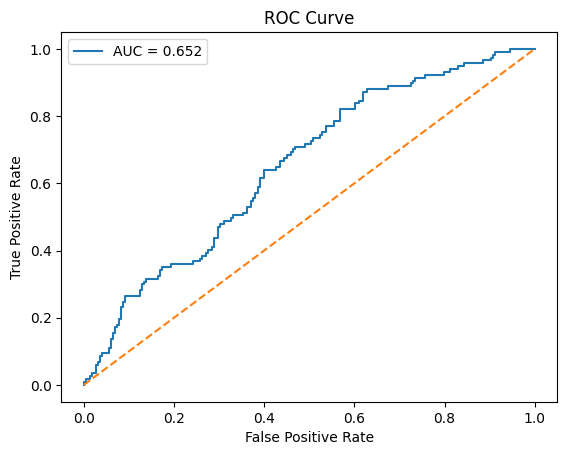

In [16]:
# Plots the ROC curve for the final model iteration and displays the corresponding AUC value
plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [17]:
# Determines the optimal decision threshold using Youden's J statistic
# Maximizes True Positive Rate and Minimizes False Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.6271026134490967


In [18]:
# Upgraded Project Main Limitations:
    # Class Imbalance
        # The dataset remains imbalanced (1086 benign vs 594 pathogenic), which may bias predictions toward the majority class and distort performance metrics.
    # Degenerate Predictions in Some Runs
        # In certain iterations, the model collapses to predicting a single class, resulting in undefined precision/recall for the minority class and warnings
        # "Precision is ill-defined and being set to 0.0 due to no predicted samples"
    # Limited Dataset Size and Diversity
        # Removal of EGFR and MYH7 reduced overall dataset size, limiting exposure to diverse mutation patterns and restricting generalization across genes.    
    # Residual Variance in Evaluation
        # Despite using 50 train-test splits, performance metrics (and ROC-AUC curves) still vary across runs due to stochastic training, random train-test splitting, and limited/imbalanced data
    # Lack Of Positional Information
        # Model does not explicitly incorporate mutation position within the protein sequence.
        # Does not directly account for region-specific functional importance, such as conserved domains or known mutational hotspots.
        # May limit its ability to distinguish between mutations occurring in functionally critical versus more tolerant regions.   
    # Lack of Cross-Validation
        # The model does not use k-fold cross-validation, relying instead on repeated random train-test splits. 
        # k-fold cross-validation ensures that every data point in test-training splits are accounted for in model evaluation, providing a more robust estimate of model performance.
        # May lead to higher variance in performance estimates and reduces the robustness of reported metrics, as results may depend on specific data partitions.
    # ROC-AUC Curve Analysis
        # Default decision threshold of 0.50 was used across all 50 train-test splits rather than determining an optimal threshold for each split using ROC analysis (e.g., Youden's J statistic)
        # ROC curve and ROC-AUC score were generated only for the final train-test split rather than averaged across all 50 iterations